# Визуальный анализ оттока клиентов

Смотрю, какие группы клиентов телеком-компании уходят чаще.
Для сравнения использую простые графики.


## 1. Загрузка и проверка данных

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

DATA_PATH = Path("data/telco_customer_churn.csv")
sns.set_theme(style="whitegrid")

customers = pd.read_csv(DATA_PATH)
customers["TotalCharges"] = pd.to_numeric(customers["TotalCharges"], errors="coerce")
customers["churn_flag"] = (customers["Churn"] == "Yes").astype(int)

print(customers.shape)
print(f"Повторы customerID: {customers['customerID'].duplicated().sum()}")
print(f"Пропуски TotalCharges: {customers['TotalCharges'].isna().sum()}")
display(customers.head())

(7043, 22)
Повторы customerID: 0
Пропуски TotalCharges: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## 2. Возрастная группа и отток

In [2]:
senior_groups = customers.groupby("SeniorCitizen")["churn_flag"]
senior_churn = senior_groups.size().to_frame("customers")
senior_churn["churn_rate"] = senior_groups.mean()
senior_churn = senior_churn.rename(index={0: "Остальные клиенты", 1: "Клиенты старшего возраста"})
senior_churn = senior_churn.reset_index(names="customer_group")
senior_churn["churn_rate_pct"] = (senior_churn["churn_rate"] * 100).round(1)
display(senior_churn)

,customer_group,customers,churn_rate,churn_rate_pct
0,Остальные клиенты,5901,0.236062,23.6
1,Клиенты старшего возраста,1142,0.416813,41.7


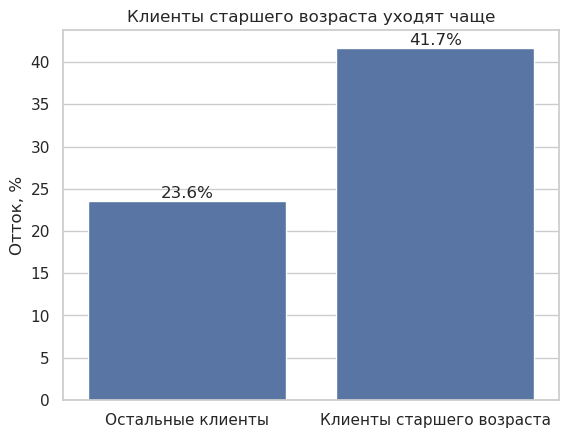

In [3]:
ax = sns.barplot(data=senior_churn, x="customer_group", y="churn_rate_pct")
ax.set(title="Клиенты старшего возраста уходят чаще", xlabel="", ylabel="Отток, %")
ax.bar_label(ax.containers[0], fmt="%.1f%%")
plt.show()

## 3. Интернет-услуги и отток

In [4]:
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

internet_customers = customers.loc[customers["InternetService"] != "No"].copy()
internet_customers["services_count"] = (
    (internet_customers[service_columns] == "Yes").sum(axis=1)
)

service_groups = internet_customers.groupby(
    ["InternetService", "services_count"]
)["churn_flag"]
churn_by_services = service_groups.size().to_frame("customers")
churn_by_services["churn_rate"] = service_groups.mean()
churn_by_services = churn_by_services.reset_index()
churn_by_services["churn_rate_pct"] = (churn_by_services["churn_rate"] * 100).round(1)

display(churn_by_services)

,InternetService,services_count,customers,churn_rate,churn_rate_pct
0,DSL,0,294,0.411565,41.2
1,DSL,1,415,0.322892,32.3
2,DSL,2,454,0.202643,20.3
3,DSL,3,475,0.130526,13.1
4,DSL,4,359,0.091922,9.2
5,DSL,5,281,0.053381,5.3
6,DSL,6,143,0.013986,1.4
7,Fiber optic,0,399,0.604010,60.4
8,Fiber optic,1,551,0.558984,55.9
9,Fiber optic,2,579,0.480138,48.0


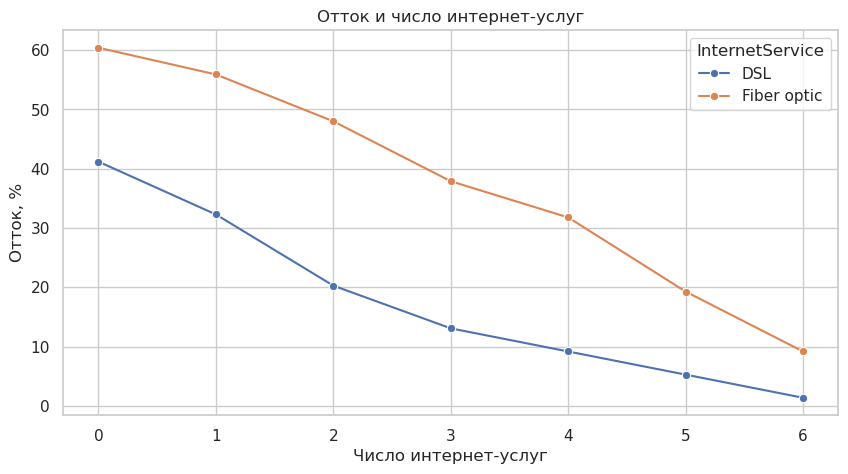

In [5]:
plt.figure(figsize=(10, 5))
ax = sns.lineplot(
    data=churn_by_services,
    x="services_count",
    y="churn_rate_pct",
    hue="InternetService",
    marker="o",
)
ax.set(
    title="Отток и число интернет-услуг",
    xlabel="Число интернет-услуг",
    ylabel="Отток, %",
)
plt.show()

## 4. Тип договора и ежемесячные платежи

In [6]:
contract_groups = customers.groupby("Contract")
contract_summary = contract_groups["customerID"].size().to_frame("customers")
contract_summary["churn_rate"] = contract_groups["churn_flag"].mean()
contract_summary["median_monthly_charge"] = contract_groups["MonthlyCharges"].median()
contract_summary = contract_summary.sort_values("churn_rate", ascending=False)
contract_summary["churn_rate_pct"] = (contract_summary["churn_rate"] * 100).round(1)

display(contract_summary)
highest_contract = contract_summary["churn_rate"].idxmax()
print(f"Общая доля оттока: {customers['churn_flag'].mean():.1%}")
print(f"Договор с самым высоким оттоком: {highest_contract}")


,customers,churn_rate,median_monthly_charge,churn_rate_pct
Contract,,,,
Month-to-month,3875,0.427097,73.25,42.7
One year,1473,0.112695,68.75,11.3
Two year,1695,0.028319,64.35,2.8


Общая доля оттока: 26.5%
Договор с самым высоким оттоком: Month-to-month


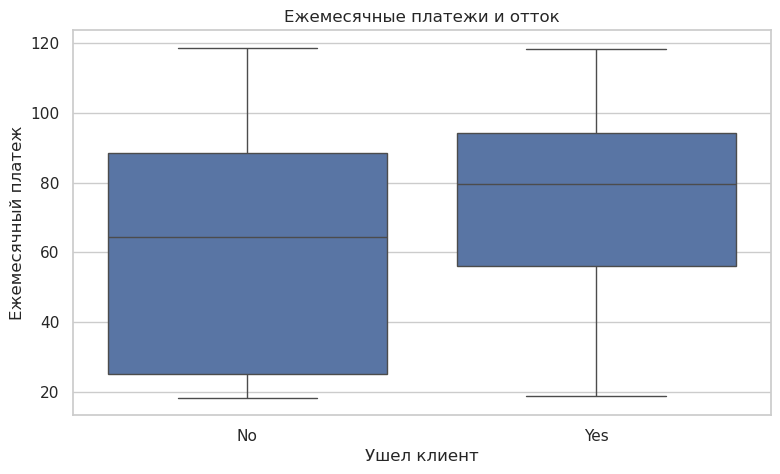

In [7]:
plt.figure(figsize=(9, 5))
ax = sns.boxplot(data=customers, x="Churn", y="MonthlyCharges")
ax.set(
    title="Ежемесячные платежи и отток",
    xlabel="Ушел клиент",
    ylabel="Ежемесячный платеж",
)
plt.show()

## 5. Выводы